Shape: (2200, 8)

Columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']

Null values:
 N              False
P              False
K              False
temperature    False
humidity       False
ph             False
rainfall       False
label          False
dtype: bool

Number of crops: 22
Crops: ['rice' 'maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans'
 'mungbean' 'blackgram' 'lentil' 'pomegranate' 'banana' 'mango' 'grapes'
 'watermelon' 'muskmelon' 'apple' 'orange' 'papaya' 'coconut' 'cotton'
 'jute' 'coffee']

Train size : 1540 samples
Test  size : 660 samples

  SOFT VOTING ENSEMBLE
Soft Voting — Test Accuracy  : 0.9955
Soft Voting — Train Accuracy : 1.0000

  STACKING ENSEMBLE  (meta-learner: Logistic Regression)
Stacking — Test Accuracy  : 0.9939
Stacking — Train Accuracy : 1.0000

  INDIVIDUAL MODEL COMPARISON
LightGBM             | Train: 1.0000  Test: 0.9939  CV: 0.9932 ± 0.0014
XGBoost              | Train: 1.0000  Test: 0.9939  CV: 0.9932 ± 0.00

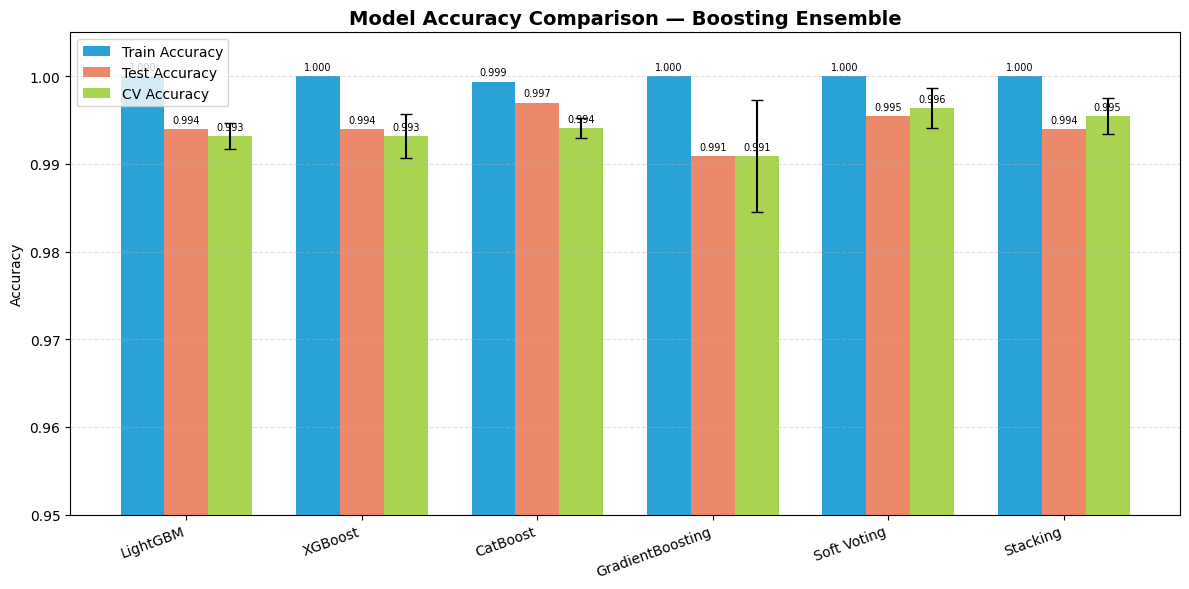

Saved: model_accuracy_comparison.png


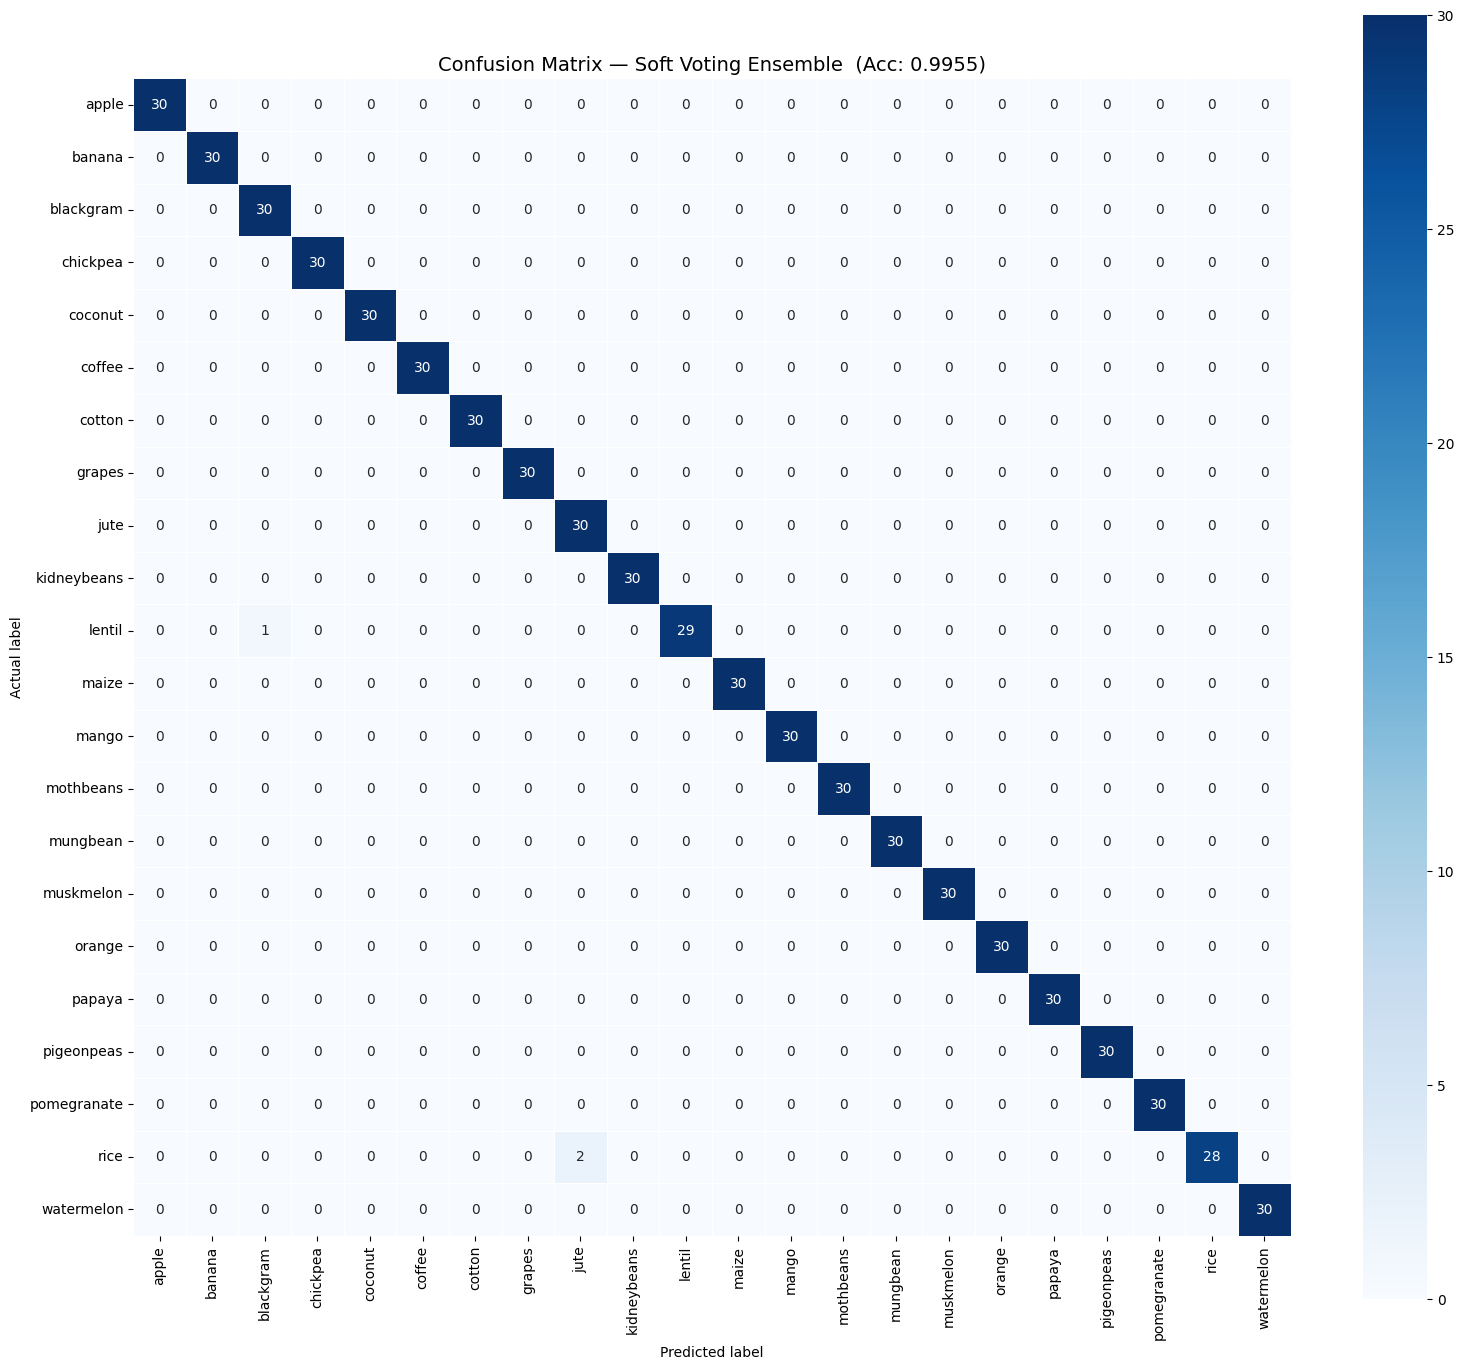

Saved: confusion_matrix_voting.png


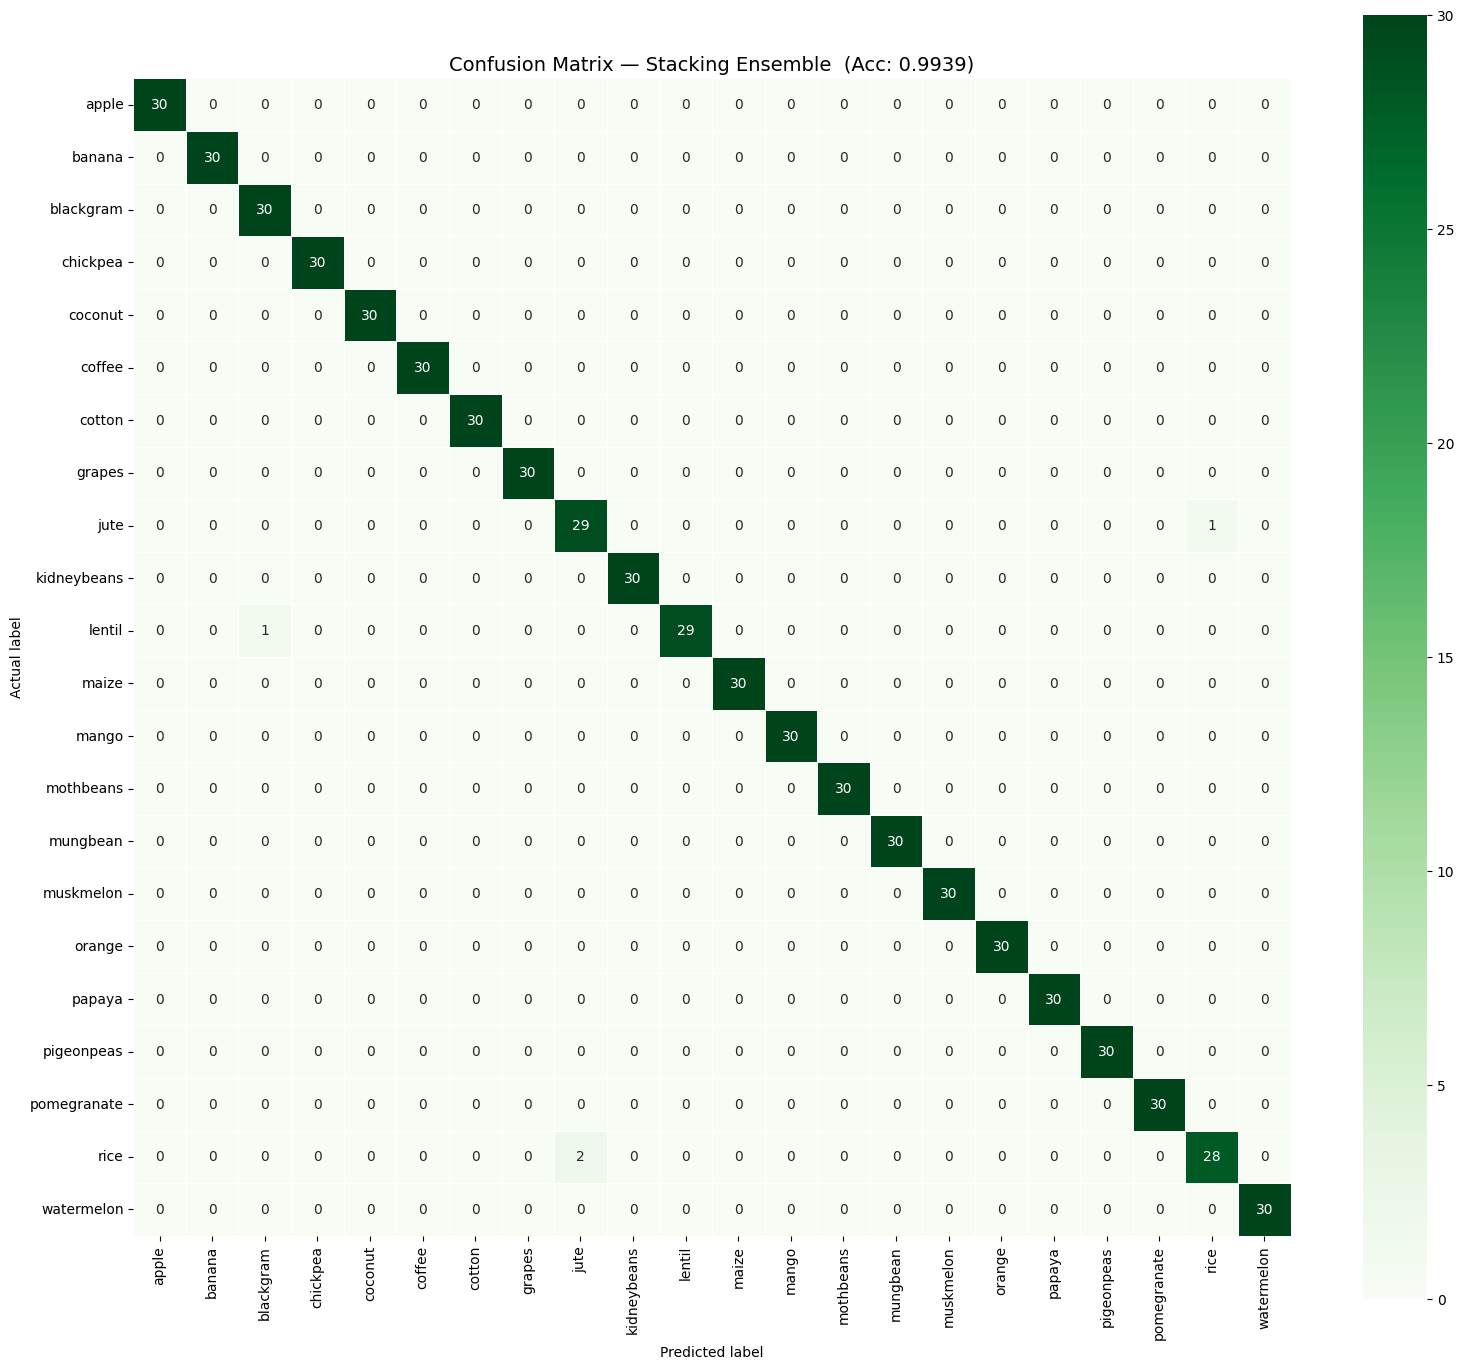

Saved: confusion_matrix_stacking.png


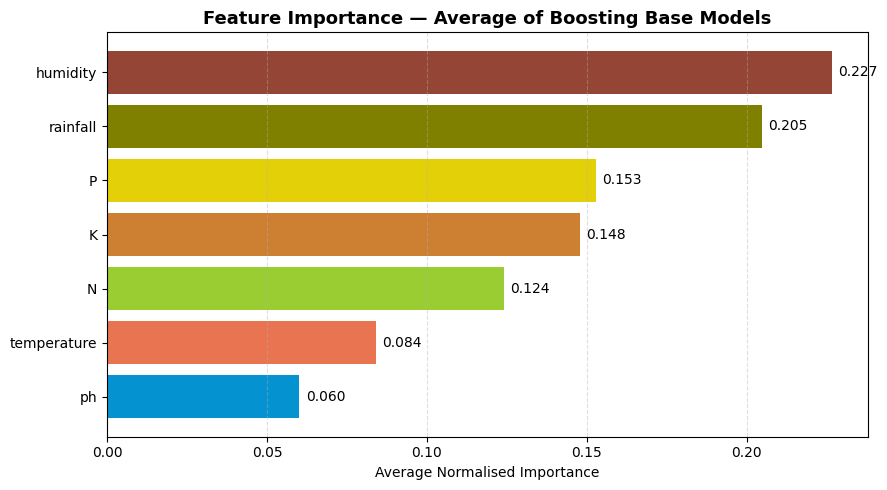

Saved: feature_importance.png


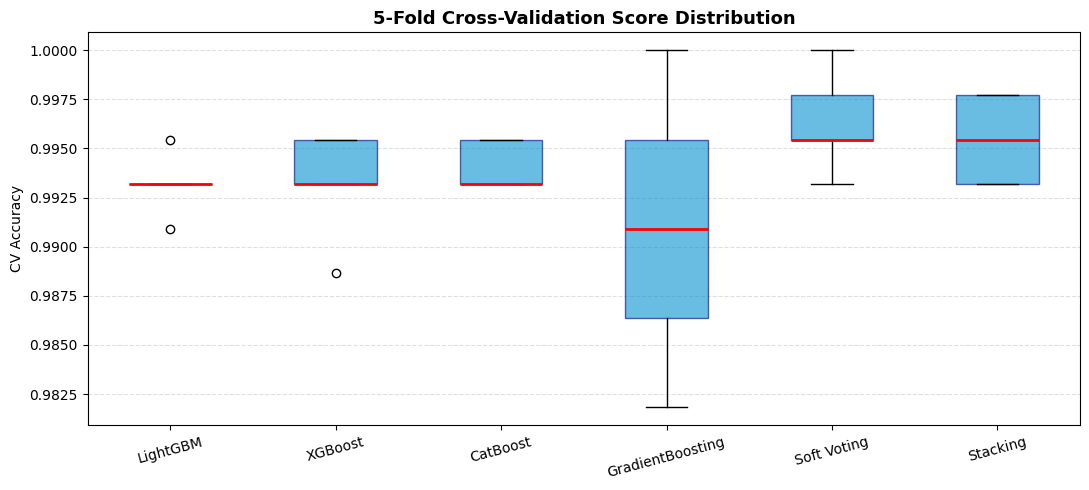

Saved: cv_score_distribution.png

  CLASSIFICATION REPORT — Soft Voting Ensemble
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        30
      banana       1.00      1.00      1.00        30
   blackgram       0.97      1.00      0.98        30
    chickpea       1.00      1.00      1.00        30
     coconut       1.00      1.00      1.00        30
      coffee       1.00      1.00      1.00        30
      cotton       1.00      1.00      1.00        30
      grapes       1.00      1.00      1.00        30
        jute       0.94      1.00      0.97        30
 kidneybeans       1.00      1.00      1.00        30
      lentil       1.00      0.97      0.98        30
       maize       1.00      1.00      1.00        30
       mango       1.00      1.00      1.00        30
   mothbeans       1.00      1.00      1.00        30
    mungbean       1.00      1.00      1.00        30
   muskmelon       1.00      1.00      1.00        30


In [2]:
# ============================================================
#  Crop Recommendation — Ensemble Boosting Model
#  Models: LightGBM | XGBoost | CatBoost | GradientBoosting
#  Ensemble: Soft Voting  +  Stacking (meta-learner)
# ============================================================
!pip install catboost

import pandas as pd
import numpy as np
import random
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

# ── Boosting models ──────────────────────────────────────────
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.ensemble import (GradientBoostingClassifier,
                               VotingClassifier,
                               StackingClassifier)
from sklearn.linear_model import LogisticRegression

# ── Utilities ────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix)

colorarr = ['#0592D0','#Cd7f32', '#E97451', '#Bdb76b', '#954535',
            '#C2b280', '#808000', '#E4d008', '#9acd32', '#32cd32']

# ════════════════════════════════════════════════════════════
# 1. IMPORT DATASET
# ════════════════════════════════════════════════════════════
cropdf = pd.read_csv("Crop_recommendation.csv")

print("Shape:", cropdf.shape)
print("\nColumns:", cropdf.columns.tolist())
print("\nNull values:\n", cropdf.isnull().any())
print("\nNumber of crops:", len(cropdf['label'].unique()))
print("Crops:", cropdf['label'].unique())

crop_summary = pd.pivot_table(cropdf, index=['label'], aggfunc='mean')

# ════════════════════════════════════════════════════════════
# 2. FEATURE & TARGET SPLIT
# ════════════════════════════════════════════════════════════
X = cropdf.drop('label', axis=1)
y = cropdf['label']

# Encode labels to integers (required by XGBoost / sklearn metrics)
le = LabelEncoder()
y_enc = le.fit_transform(y)

# ════════════════════════════════════════════════════════════
# 3. TRAIN / TEST SPLIT
# ════════════════════════════════════════════════════════════
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.3, shuffle=True, random_state=0, stratify=y_enc
)

print(f"\nTrain size : {X_train.shape[0]} samples")
print(f"Test  size : {X_test.shape[0]} samples")

# ════════════════════════════════════════════════════════════
# 4. DEFINE INDIVIDUAL BOOSTING MODELS
# ════════════════════════════════════════════════════════════

lgbm_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,
    random_state=42,
    verbose=-1
)

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    verbosity=0,
    random_state=42
)

cat_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    random_state=42,
    verbose=0
)

gb_model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    random_state=42
)

# ════════════════════════════════════════════════════════════
# 5. SOFT VOTING ENSEMBLE
# ════════════════════════════════════════════════════════════
print("\n" + "="*55)
print("  SOFT VOTING ENSEMBLE")
print("="*55)

voting_model = VotingClassifier(
    estimators=[
        ('lgbm',    lgbm_model),
        ('xgb',     xgb_model),
        ('catboost',cat_model),
        ('gradboost',gb_model)
    ],
    voting='soft'          # averages predicted probabilities
)

voting_model.fit(X_train, y_train)
y_pred_vote = voting_model.predict(X_test)

vote_acc = accuracy_score(y_test, y_pred_vote)
print(f"Soft Voting — Test Accuracy  : {vote_acc:.4f}")
print(f"Soft Voting — Train Accuracy : {accuracy_score(y_train, voting_model.predict(X_train)):.4f}")

# ════════════════════════════════════════════════════════════
# 6. STACKING ENSEMBLE  (meta-learner = Logistic Regression)
# ════════════════════════════════════════════════════════════
print("\n" + "="*55)
print("  STACKING ENSEMBLE  (meta-learner: Logistic Regression)")
print("="*55)

stacking_model = StackingClassifier(
    estimators=[
        ('lgbm', lgb.LGBMClassifier(n_estimators=100)),
        ('xgb', xgb.XGBClassifier(n_estimators=100, verbosity=0))
    ],
    final_estimator=LogisticRegression(max_iter=500),
    cv=3,
    n_jobs=-1
)

stacking_model.fit(X_train, y_train)
y_pred_stack = stacking_model.predict(X_test)

stack_acc = accuracy_score(y_test, y_pred_stack)
print(f"Stacking — Test Accuracy  : {stack_acc:.4f}")
print(f"Stacking — Train Accuracy : {accuracy_score(y_train, stacking_model.predict(X_train)):.4f}")

# ════════════════════════════════════════════════════════════
# 7. INDIVIDUAL MODEL ACCURACIES  (for comparison bar chart)
# ════════════════════════════════════════════════════════════
print("\n" + "="*55)
print("  INDIVIDUAL MODEL COMPARISON")
print("="*55)

individual_models = {
    'LightGBM':        lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, verbose=-1, random_state=42),
    'XGBoost':         xgb.XGBClassifier(n_estimators=300, learning_rate=0.05, use_label_encoder=False,
                                          eval_metric='mlogloss', verbosity=0, random_state=42),
    'CatBoost':        CatBoostClassifier(iterations=300, learning_rate=0.05, verbose=0, random_state=42),
    'GradientBoosting':GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, random_state=42),
    'Soft Voting':     voting_model,          # already trained
    'Stacking':        stacking_model         # already trained
}

results = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in individual_models.items():
    if name not in ('Soft Voting', 'Stacking'):
        model.fit(X_train, y_train)
    test_acc  = accuracy_score(y_test,  model.predict(X_test))
    train_acc = accuracy_score(y_train, model.predict(X_train))
    cv_scores = cross_val_score(model, X, y_enc, cv=skf, scoring='accuracy')
    results[name] = {
        'train_acc': train_acc,
        'test_acc':  test_acc,
        'cv_mean':   cv_scores.mean(),
        'cv_std':    cv_scores.std()
    }
    print(f"{name:<20} | Train: {train_acc:.4f}  Test: {test_acc:.4f}  "
          f"CV: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# ════════════════════════════════════════════════════════════
# 8. VISUALISATIONS
# ════════════════════════════════════════════════════════════

# ── 8a  Model Accuracy Comparison ───────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
names   = list(results.keys())
train_a = [results[n]['train_acc'] for n in names]
test_a  = [results[n]['test_acc']  for n in names]
cv_a    = [results[n]['cv_mean']   for n in names]
cv_e    = [results[n]['cv_std']    for n in names]

x = np.arange(len(names))
w = 0.25
bars1 = ax.bar(x - w, train_a, w, label='Train Accuracy', color='#0592D0', alpha=0.85)
bars2 = ax.bar(x,     test_a,  w, label='Test Accuracy',  color='#E97451', alpha=0.85)
bars3 = ax.bar(x + w, cv_a,    w, label='CV Accuracy',    color='#9acd32', alpha=0.85,
               yerr=cv_e, capsize=4)

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=20, ha='right')
ax.set_ylim(0.95, 1.005)
ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy Comparison — Boosting Ensemble', fontsize=14, fontweight='bold')
ax.legend()
ax.set_facecolor('white')
ax.grid(axis='y', linestyle='--', alpha=0.4)

for bar in [*bars1, *bars2, *bars3]:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('model_accuracy_comparison.png', dpi=150)
plt.show()
print("Saved: model_accuracy_comparison.png")

# ── 8b  Confusion Matrix — Soft Voting ──────────────────────
cm_vote = confusion_matrix(y_test, y_pred_vote)
plt.figure(figsize=(16, 14))
sns.heatmap(cm_vote, annot=True, fmt='.0f', linewidths=.5,
            square=True, cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.title(f'Confusion Matrix — Soft Voting Ensemble  (Acc: {vote_acc:.4f})', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrix_voting.png', dpi=150)
plt.show()
print("Saved: confusion_matrix_voting.png")

# ── 8c  Confusion Matrix — Stacking ─────────────────────────
cm_stack = confusion_matrix(y_test, y_pred_stack)
plt.figure(figsize=(16, 14))
sns.heatmap(cm_stack, annot=True, fmt='.0f', linewidths=.5,
            square=True, cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.title(f'Confusion Matrix — Stacking Ensemble  (Acc: {stack_acc:.4f})', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrix_stacking.png', dpi=150)
plt.show()
print("Saved: confusion_matrix_stacking.png")

# ── 8d  Feature Importance — average across base models ─────
fi_lgbm = individual_models['LightGBM'].feature_importances_
fi_xgb  = individual_models['XGBoost'].feature_importances_
fi_gb   = individual_models['GradientBoosting'].feature_importances_
avg_fi  = (fi_lgbm / fi_lgbm.sum() + fi_xgb / fi_xgb.sum() + fi_gb / fi_gb.sum()) / 3

fi_df = pd.DataFrame({'Feature': X.columns, 'Importance': avg_fi})
fi_df = fi_df.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(fi_df['Feature'], fi_df['Importance'],
        color=['#0592D0','#E97451','#9acd32','#Cd7f32','#E4d008','#808000','#954535'])
ax.set_xlabel('Average Normalised Importance')
ax.set_title('Feature Importance — Average of Boosting Base Models', fontsize=13, fontweight='bold')
ax.set_facecolor('white')
ax.grid(axis='x', linestyle='--', alpha=0.4)
for i, (val, feat) in enumerate(zip(fi_df['Importance'], fi_df['Feature'])):
    ax.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print("Saved: feature_importance.png")

# ── 8e  CV Score Distribution — box plot ────────────────────
cv_data = {}
for name, model in individual_models.items():
    scores = cross_val_score(model, X, y_enc, cv=skf, scoring='accuracy')
    cv_data[name] = scores

fig, ax = plt.subplots(figsize=(11, 5))
ax.boxplot(cv_data.values(), labels=cv_data.keys(), patch_artist=True,
           boxprops=dict(facecolor='#0592D0', color='navy', alpha=0.6),
           medianprops=dict(color='red', linewidth=2))
ax.set_ylabel('CV Accuracy')
ax.set_title('5-Fold Cross-Validation Score Distribution', fontsize=13, fontweight='bold')
ax.set_facecolor('white')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('cv_score_distribution.png', dpi=150)
plt.show()
print("Saved: cv_score_distribution.png")

# ════════════════════════════════════════════════════════════
# 9. CLASSIFICATION REPORT
# ════════════════════════════════════════════════════════════
print("\n" + "="*55)
print("  CLASSIFICATION REPORT — Soft Voting Ensemble")
print("="*55)
print(classification_report(y_test, y_pred_vote, target_names=le.classes_))

print("\n" + "="*55)
print("  CLASSIFICATION REPORT — Stacking Ensemble")
print("="*55)
print(classification_report(y_test, y_pred_stack, target_names=le.classes_))

# ════════════════════════════════════════════════════════════
# 10. PREDICT ON NEW DATA
# ════════════════════════════════════════════════════════════
print("\n" + "="*55)
print("  PREDICT ON NEW SAMPLE")
print("="*55)
# [N, P, K, temperature, humidity, ph, rainfall]
new_sample = [[90, 42, 43, 20.879744, 75, 5.5, 220]]

pred_vote  = le.inverse_transform(voting_model.predict(new_sample))
pred_stack = le.inverse_transform(stacking_model.predict(new_sample))

print(f"Input     : N=90, P=42, K=43, Temp=20.88, Humidity=75, pH=5.5, Rainfall=220")
print(f"Soft Voting Prediction : {pred_vote[0]}")
print(f"Stacking   Prediction  : {pred_stack[0]}")


In [ ]:
import joblib
joblib.dump({
    "voting_model": voting_model,
    "stacking_model": stacking_model,
    "label_encoder": le
}, "crop_model_all.pkl")

['crop_model_all.pkl']